In [18]:
import pandas as pd
import numpy as np

columns = [ "Dead On Arrival", "Early Loss", "Partial Mission", "Full Mission", "Unknown" ]

data = {
    "all": [
        [13, [69.2,7.7,7.7,15.4,0]],
        [33, [39.4,15.2,12.1,33.3,0]],
        [158,[23.4,14.6,36.7,25.3,0]],
        [292,[13.7,8.9,24.7,16.1,36.6]],
    ],
    "SmallSat Developer": [
        [5,[60,0,0,40,0]],
        [15,[26.7,6.7,13.3,53.3,0]],
        [49,[8.2,14.3,44.9,32.7,0]],
        [88,[11.4,13.6,40.9,34.1,0]],
    ],
    "Hobbyist": [
        [8,[75,12.5,12.5,0,0]],
        [17,[41.2,23.5,11.8,23.5,0]],
        [79,[39.2,17.7,22.8,20.3,0]],
        [86,[34.9,16.3,34.9,14,0]]
    ],
}

In [44]:
data_aggregate = {}
for k, v in data.items():
    data_aggregate[k] = np.array([0.0 for c in columns])
    for j in v:
        data_aggregate[k] += np.array(j[1]) / 100 * j[0]

df = pd.DataFrame.from_dict(data_aggregate,orient='index',columns=columns).round()
df = df.drop(["all"])

df

,Dead On Arrival,Early Loss,Partial Mission,Full Mission,Unknown
SmallSat Developer,21.0,20.0,60.0,56.0,0.0
Hobbyist,74.0,33.0,51.0,32.0,0.0


TypeError: 'LinearSegmentedColormap' object is not subscriptable

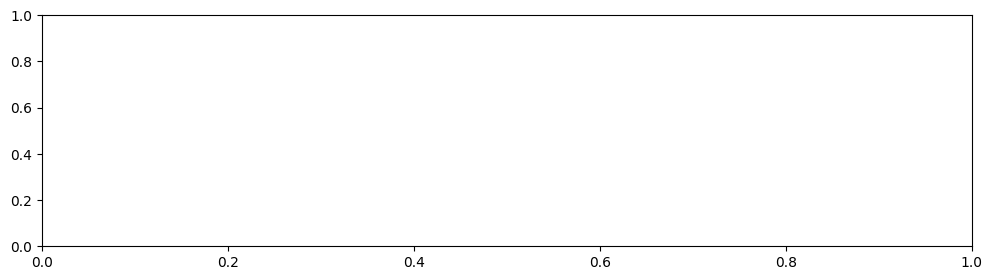

In [101]:
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

df_percentage = (df.div(df.sum(axis=1), axis=0) * 100).drop("Unknown", axis=1)

#colors = plt.cm.RdYlGn(np.linspace(0, 1, len(columns)))
colors = LinearSegmentedColormap.from_list("badgood", [ 'tab:orange', 'tab:green' ]).resampled(len(columns))

fig, ax = plt.subplots(figsize=(12, 3))

y_pos = np.arange(len(df_percentage))

# Create horizontal stacked bar chart
left = np.zeros(len(df_percentage))
for i, col in enumerate(df_percentage.columns):
    values = df_percentage[col].values
    ax.barh(y_pos, values, left=left, label=col, color=colors[i], height=0.6)
    
    # Add text labels inside bars
    for j, (idx, row) in enumerate(df_percentage.iterrows()):
        val = row[col]
        if val > 0:
            #pct = val / df.iloc[j].sum() * 100
            pct = df_percentage.iloc[j, i]
            actual = df.iloc[j, i]
            ax.text(left[j] + pct / 2, j -0.02, f'{col}', 
                  va='bottom', ha='center', fontsize=10, fontweight='bold', color='white')
            ax.text(left[j] + pct / 2, j -0.02, f'{pct:.1f}% ({actual:.0f})', 
                  va='top', ha='center', fontsize=9, color='white')
    left += values

ax.set_yticks(y_pos)
ax.set_yticklabels(df.index)
ax.set_xlabel('Count')
ax.set_title('Mission Outcomes by Developer Type')
#ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()
